# Detecção e Contagem Automática de Pontos nas Faces de Dados com Visão Computacional

## Sobre o Projeto

Este projeto consiste em um pipeline completo de Visão Computacional para identificação e contagem automática dos pontos presentes em faces de dados.

A solução utiliza técnicas clássicas de processamento digital de imagens para segmentar os pontos brancos, remover ruídos, identificar contornos e calcular automaticamente a pontuação total presente em cada imagem.

### Objetivo

Desenvolver um sistema capaz de:

- Detectar automaticamente os pontos visíveis nas faces dos dados de jogo;
- Realizar segmentação de objetos utilizando limiarização;
- Aplicar operações morfológicas para redução de ruídos;
- Identificar contornos correspondentes aos pontos detectados;
- Calcular automaticamente a quantidade total de pontos presentes na imagem.

### Resultado

- Impressão no console com a mensagem:
    * Total da pontuação: 'X' (onde X é a contagem dos pontos brancos).
- Exibição visual da imagem com os contornos desenhados em verde sobre os pontos brancos detectados.

# 0.0 Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Funções auxiliares

In [2]:
def plot_image(image, title, nrow, ncol, idx, cmap_type='gray', axis_off=True):
    """
    Exibe uma imagem em um subplot dentro de uma grade de visualizações.
    
    Parametros
    ----------
    image : numpy.ndarray
        Imagem a ser exibida. Pode ser em escala de cinza (2D) ou colorida (3D).
        Para imagens coloridas, espera-se formato (altura, largura, canais).
    title : str
        Título do subplot que será exibido acima da imagem.
    nrow : int
        Número total de linhas na grade de subplots.
    ncol : int
        Número total de colunas na grade de subplots.
    idx : int
        Índice posicional do subplot atual (começa em 1).
    cmap_type : str, optional
        Mapa de cores utilizado para exibição de imagens em escala de cinza.
        Padrão é 'gray'. Este parâmetro é ignorado automaticamente quando a imagem possui 3 canais (colorida).
    axis_off : bool, optional
        Se True (padrão), desabilita a exibição dos eixos (rótulos e ticks).
        Se False, mantém os eixos visíveis.
    """         
    plt.subplot(nrow, ncol, idx)
    if len(image.shape) == 3:
        cmap_type = None
    plt.imshow(image, cmap=cmap_type)  
    plt.title(title)
    if axis_off:
        plt.axis('off')

# 1. def read_img(img_path):

In [3]:
def read_img(img_path, imagem):
    '''
    Função:
    Ler a imagem com OpenCV e converter de BGR para RGB.
    
    Parâmetros de entrada:
    -----------
    img_path : str
        Caminho completo da imagem.
    imagem : str
        nome do arquivo da imagem com a extensão .jpg
    
    saída:
    -----------    
    image_rgb: image_rgb
        Imagem colorida em RGB.
    '''

    path = img_path
    file = imagem

    # Carregar imagem bgr
    image_bgr = cv2.imread(path+file)
    
    # Converter para RGB
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    return image_rgb

In [4]:
caminho = "../data/imagem/"
imagem = 'dados_01.jpg'

imagem_1 = read_img(caminho,imagem)

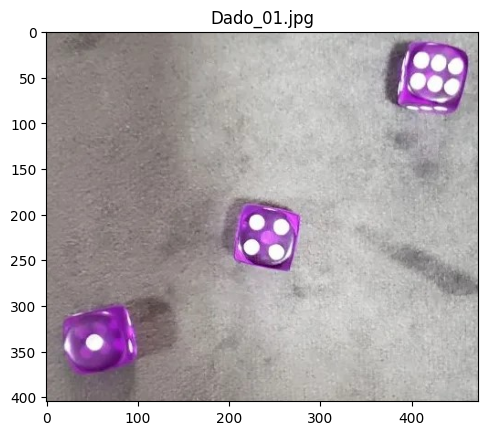

In [5]:
plot_image(imagem_1, 'Dado_01.jpg',1,1,1, axis_off=False)

# 2. def binarized(img_gray):

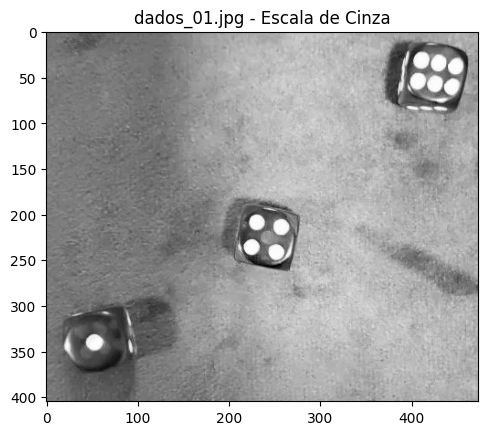

In [6]:
# Carregando uma imagem em escala de cinza
imagem_gray = cv2.cvtColor(imagem_1, cv2.COLOR_RGB2GRAY)
plot_image(imagem_gray, 'dados_01.jpg - Escala de Cinza',1,1,1, axis_off=False)

In [7]:
# Criando a função de binarização de imagens 
def binarized(imagem, lm_inferior, lm_superior, binary=True):
    '''
    Função: Aplicar limiarização thresholding para destacar apenas os pontos brancos na imagem.
    
    Parâmetros de entrada:
    ----------- 
    imagem      --> Imagem em escala de cinza.
    lm_inferior --> Limiar inferior da escala (0-255) que será destacado na transformacao
    limiar_max  --> Limiar superior da escala (0-255) que será destacado na transformacao
    binary      --> Tipo da transformação: (padrão=True) 'BINARY': pixels da região limite claros e o fundo da imagem escuro / (False)'BINARY_INV' deixa os pixels da região limite escuro e o fundo da imagem claro
    
    Saída:
    ----------- 
    img_binarizada : numpy.ndarray
        Imagem binarizada (preto e branco), onde os pontos brancos aparecem como regiões claras.
    '''
    img_gray = imagem
    limiar_min = lm_inferior
    limiar_max = lm_superior
    if binary:
        th, img_binarizada = cv2.threshold(img_gray, limiar_min, limiar_max, cv2.THRESH_BINARY)
    else:
        th, img_binarizada = cv2.threshold(img_gray, limiar_min, limiar_max, cv2.THRESH_BINARY_INV)
    return img_binarizada

In [8]:
# utilizando a função binarizada
img_bin = binarized(imagem_gray, 240, 255)

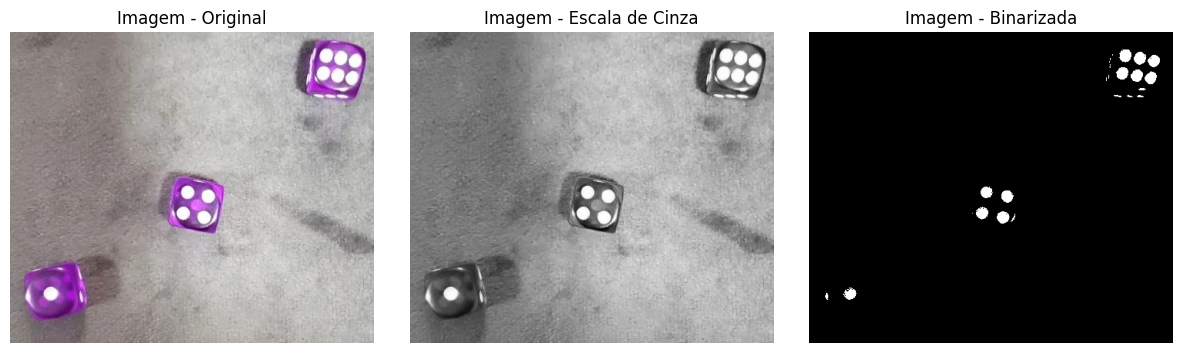

In [9]:
plt.figure(figsize=(15, 8))

plot_image(imagem_1, "Imagem - Original", 1, 3, 1)
plot_image(imagem_gray, "Imagem - Escala de Cinza", 1, 3, 2)
plot_image(img_bin, "Imagem - Binarizada", 1, 3, 3)
plt.subplots_adjust(wspace=0.1)
plt.show()

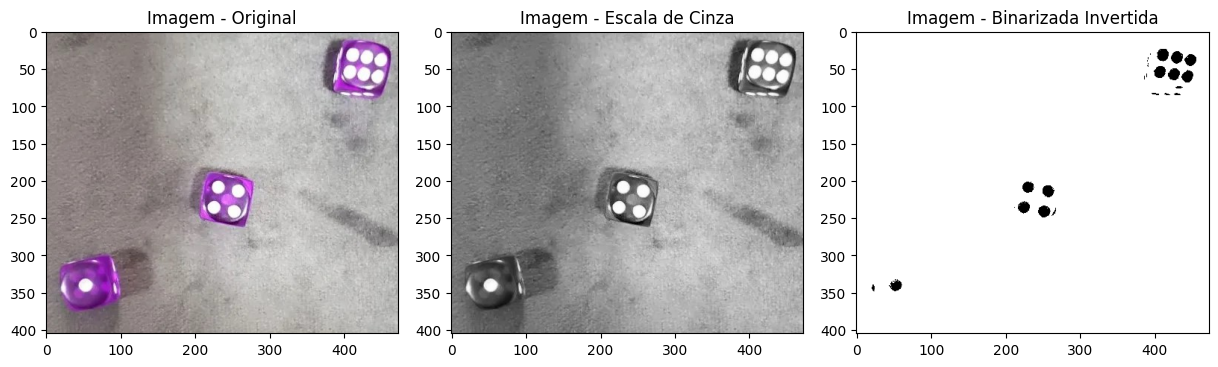

In [10]:
# utilizando a função binarizada invertida 
img_bin_inv = binarized(imagem_gray, 240, 255, binary=False)

plt.figure(figsize=(15, 8))

plot_image(imagem_1, "Imagem - Original", 1, 3, 1, axis_off=False)
plot_image(imagem_gray, "Imagem - Escala de Cinza", 1, 3, 2, axis_off=False)
plot_image(img_bin_inv, "Imagem - Binarizada Invertida", 1, 3, 3, axis_off=False)
plt.subplots_adjust(wspace=0.15)
plt.show()

# 3. def morphological_transformation(img_blur):

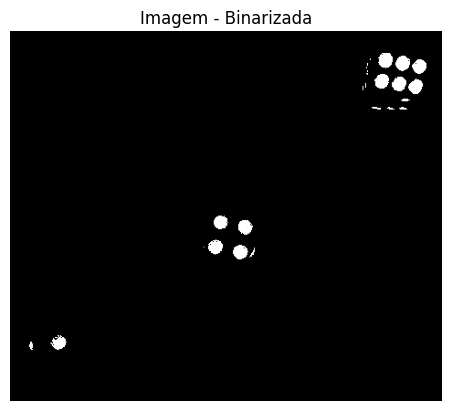

In [11]:
plot_image(img_bin, "Imagem - Binarizada", 1, 1, 1)

In [12]:
def morphological_transformation(image, kernel_size):
    """
    Função: Limpar ruídos e destacar melhor os pontos brancos com operações morfológicas.
    
    Parâmetros de entrada:
    ----------
    image : numpy.ndarray
        Imagem de entrada em escala de cinza ou binária. Deve ser um array 2D.
    kernel_size : tupla de inteiros
        Tamanho do elemento estruturante (kernel) no formato (largura, altura).
        Exemplo: (5, 5). Valores ímpares são recomendados para garantir simetria.
    
    Saída
    -------
    img_tratada3: numpy.ndarray
        Imagem processada após a aplicação sequencial de:
        1. Operação de erosão (3 iterações)
        2. Operação de dilatação (2 iterações)
        3. Filtro Gaussiano (blur)
    """        
    ksize         = kernel_size
    kernel        = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, ksize)
    img_tratada1  = cv2.erode(image, kernel, iterations=3)
    img_tratada2  = cv2.dilate(img_tratada1, kernel, iterations=2)
    img_tratada3 = cv2.GaussianBlur(img_tratada2, ksize, 0)
    return img_tratada3

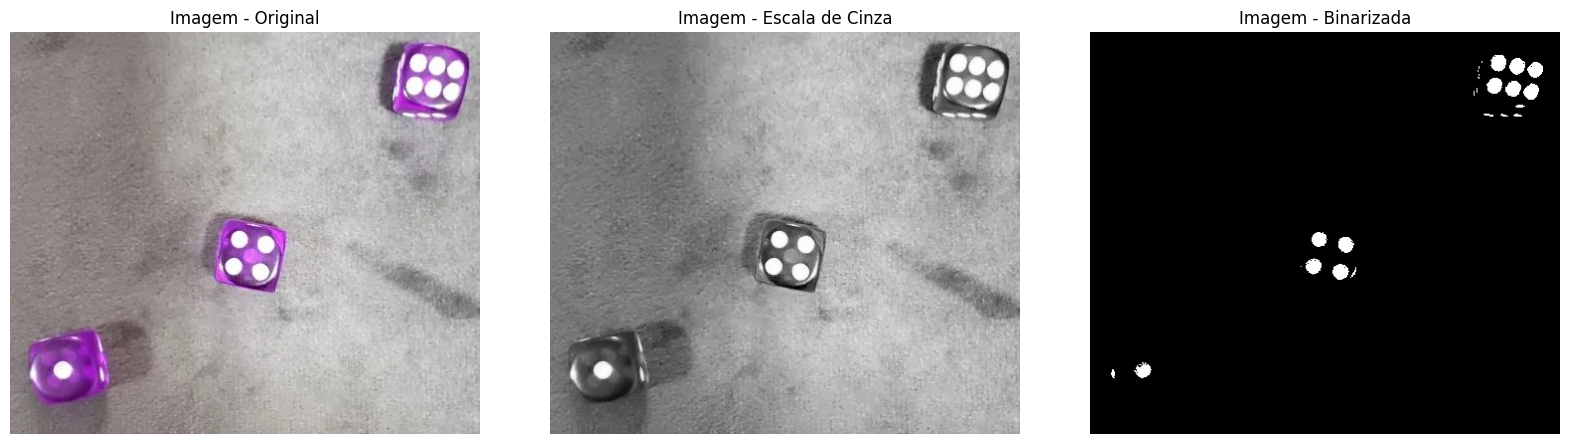

In [13]:
plt.figure( figsize=(20, 10) )

plot_image(imagem_1, "Imagem - Original", 1, 3, 1)
plot_image(imagem_gray, "Imagem - Escala de Cinza", 1, 3, 2)
plot_image(img_bin, "Imagem - Binarizada", 1, 3, 3)
plt.subplots_adjust(wspace=0.15)
plt.show()

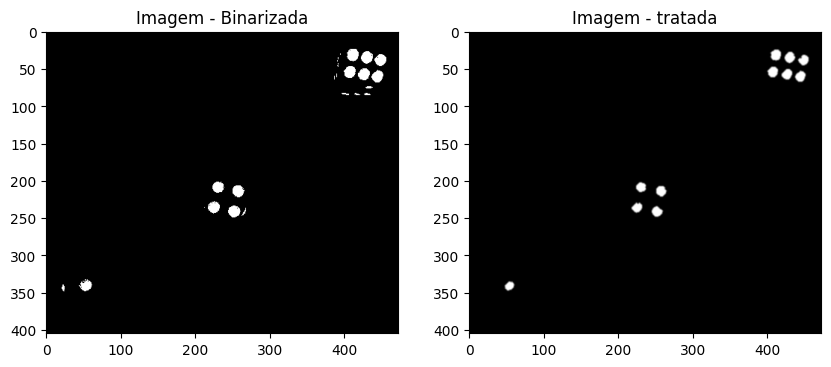

In [14]:
kernel_size  = (3,3)
imagem_morph =  morphological_transformation(img_bin, kernel_size)

plt.figure( figsize=(10, 8) )
plot_image(img_bin,      "Imagem - Binarizada", 1, 2, 1, axis_off = False)
plot_image(imagem_morph, "Imagem - tratada",  1, 2, 2, axis_off = False)

# 4. def counting(img_gaussian_blur):

In [15]:
def counting(imagem_tratada):
    '''
    Função: Encontrar os contornos dos pontos brancos presentes na imagem binarizada após as transformações morfológicas.

    Parâmetros de entrada:
    ----------
    imagem_tratada: numpy.ndarray
        --> Imagem processada após erosão, dilatação e blur.

    Saída:
    ----------
    contours  --> Lista de contornos encontrados.
    hierarchy:numpy.ndarray
        --> array 3D que descreve as relações entre os contornos (qual contorno está dentro de qual).
    '''

    # Encontrar contornos na imagem
    contours, hierarchy = cv2.findContours(
        imagem_tratada,
        cv2.RETR_EXTERNAL,         # Recupera apenas contornos externos
        cv2.CHAIN_APPROX_SIMPLE    # Compacta os pontos do contorno
    )

    return contours, hierarchy

In [16]:
imagem_contornos = counting(imagem_morph)
print("Quantidade de valores do's dado's da imagem = {}".format(len(imagem_contornos[0]) ))

Quantidade de valores do's dado's da imagem = 11


# 5. def draw_and_plot(img, contours):

In [17]:
def draw_and_plot(img, contours):
    """
    Desenha os contornos na imagem original e exibe o resultado com matplotlib.
    
    Parâmetros:
    -----------
    img : numpy.ndarray
        Imagem original em formato RGB.
    contours : list
        Lista de contornos retornada pela função counting().
    
    Saída:
    --------
    img_contours : numpy.ndarray
        Imagem RGB com os contornos desenhados na cor verde.
    """
    # Criar uma cópia da imagem original para não modificá-la diretamente
    img_contours = img.copy()
    
    # Desenhar os contornos em verde (0, 255, 0) em formato RGB
    # thickness=2 para ficar visível sem sobrecarregar visualmente
    cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
    
    # Exibir a imagem com matplotlib
    plt.figure(figsize=(8, 6))
    plt.imshow(img_contours)
    plt.title(f"Imagem Original com {len(contours)} Contornos (Verde)")
    plt.axis('off')
    plt.show()
    
    return img_contours

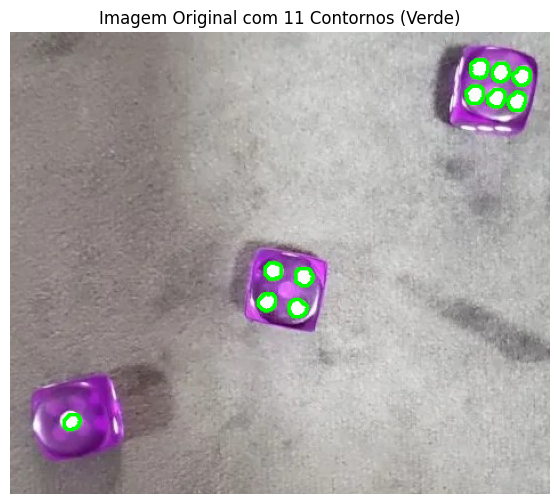

In [18]:
imagem_processada = draw_and_plot(imagem_1, imagem_contornos[0])

# 6. def run(img_path):

In [19]:
def run(img_path):
    """
    Executa todo o pipeline de processamento das imagens de dados.
    
    Parâmetros:
    -----------
    img_path : str
        Caminho completo para a imagem (ex: "../data/imagem/dados_01.jpg")
    
    Saída:
    --------
    total_pontos : int
        Quantidade total de pontos brancos detectados.
    contours : list
        Lista de contornos encontrados.
    """
    
    # 1. Lê a imagem
    print(f"Carregando imagem: {img_path}")
    imagem_rgb = cv2.imread(img_path)
    imagem_rgb = cv2.cvtColor(imagem_rgb, cv2.COLOR_BGR2RGB)
    
    # 2. Converte para tons de cinza
    imagem_gray = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)
    
    # 3. Aplica limiarização para extrair os pontos brancos
    img_bin = binarized(imagem_gray, 240, 255)
    
    # 4. Aplica filtro de gaussiano para suavização (já incluso na morphological_transformation)
    # 5. Realiza transformações morfológicas
    kernel_size = (3, 3)
    imagem_morph = morphological_transformation(img_bin, kernel_size)
    
    # 6. Detecta os contornos
    contours, hierarchy = counting(imagem_morph)
    
    # 7. Exibe o total de pontos detectados
    total_pontos = len(contours)
    print(f"Total da pontuação: {total_pontos}")
    
    # 8. Mostra a imagem com contornos desenhados
    draw_and_plot(imagem_rgb, contours)
    
    return total_pontos, contours

Carregando imagem: ../data/imagem/dados_01.jpg
Total da pontuação: 11


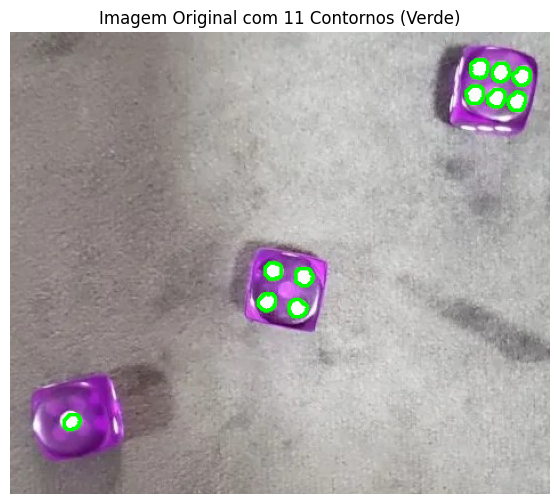

In [20]:
caminho = '../data/imagem/'
imagem = 'dados_01.jpg'

img_path = caminho+imagem

# Chamada direta
pontuacao, contornos_detectados = run(img_path)

# 7. Teste em 10 imagens

In [21]:
def processar_lote(img_paths):
    """
    Processa múltiplas imagens em loop.
    
    Parâmetros:
    -----------
    img_paths : list
        Lista com caminhos das imagens
    """
    print(f"\n--- Processando {len(img_paths)} imagens ---\n")
    
    for img_path in img_paths:
        pontuacao, _ = run(img_path)
        print(f"{img_path.split('/')[-1]}: {pontuacao} pontos\n")


--- Processando 10 imagens ---

Carregando imagem: ../data/imagem/dados_01.jpg
Total da pontuação: 11


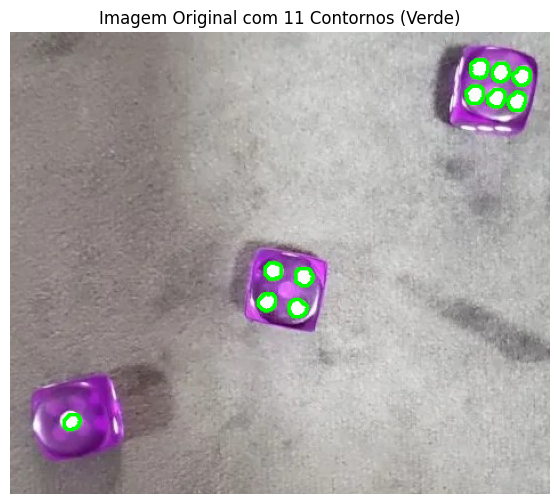

dados_01.jpg: 11 pontos

Carregando imagem: ../data/imagem/dados_02.jpg
Total da pontuação: 15


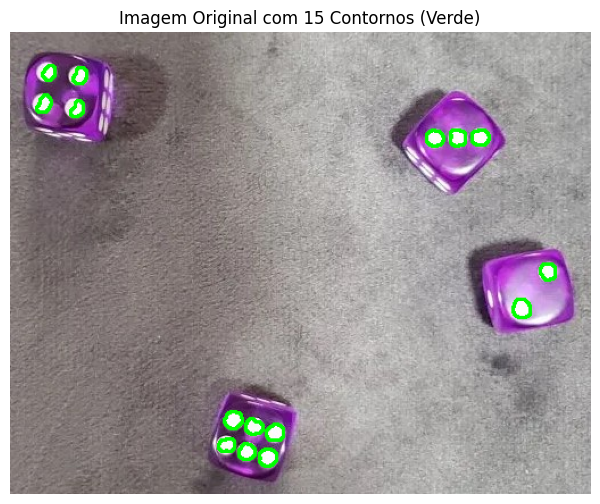

dados_02.jpg: 15 pontos

Carregando imagem: ../data/imagem/dados_03.jpg
Total da pontuação: 4


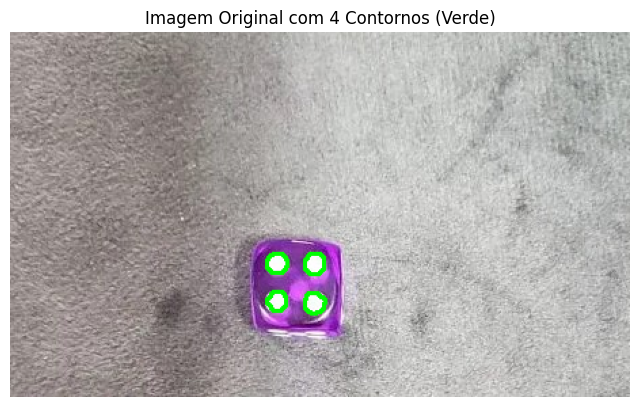

dados_03.jpg: 4 pontos

Carregando imagem: ../data/imagem/dados_04.jpg
Total da pontuação: 7


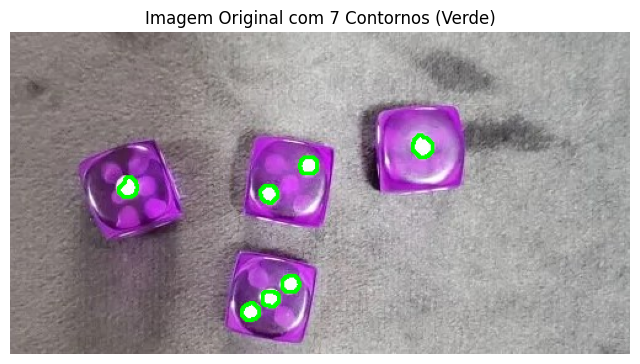

dados_04.jpg: 7 pontos

Carregando imagem: ../data/imagem/dados_05.jpg
Total da pontuação: 39


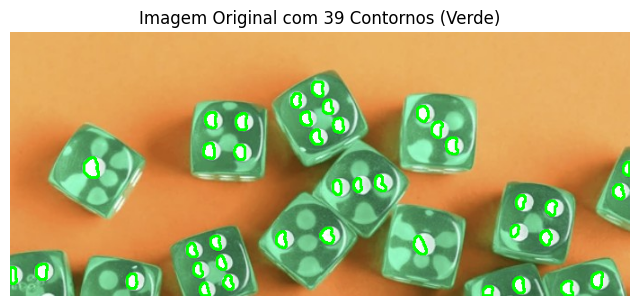

dados_05.jpg: 39 pontos

Carregando imagem: ../data/imagem/dados_06.jpg
Total da pontuação: 8


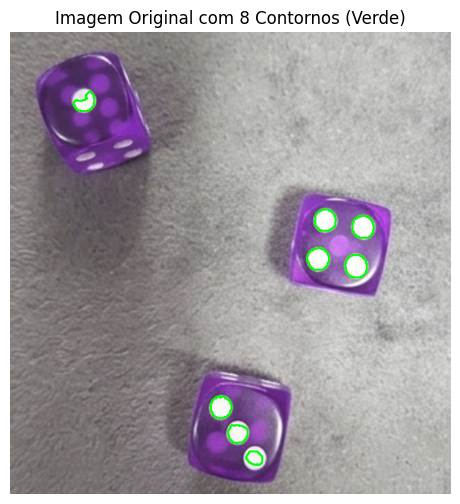

dados_06.jpg: 8 pontos

Carregando imagem: ../data/imagem/dados_07.jpg
Total da pontuação: 24


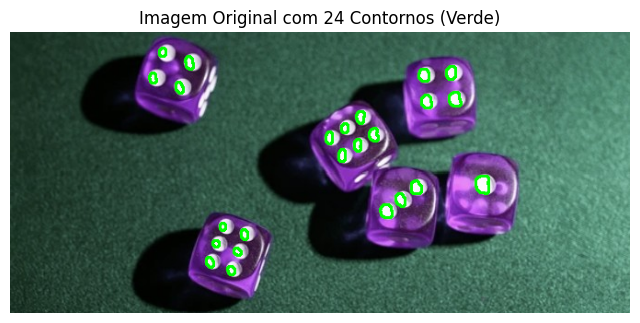

dados_07.jpg: 24 pontos

Carregando imagem: ../data/imagem/dados_08.jpg
Total da pontuação: 21


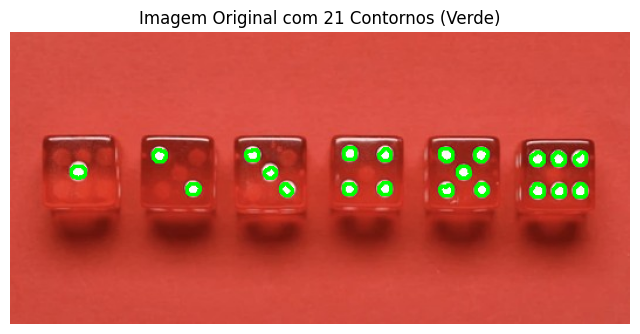

dados_08.jpg: 21 pontos

Carregando imagem: ../data/imagem/dados_09.jpg
Total da pontuação: 21


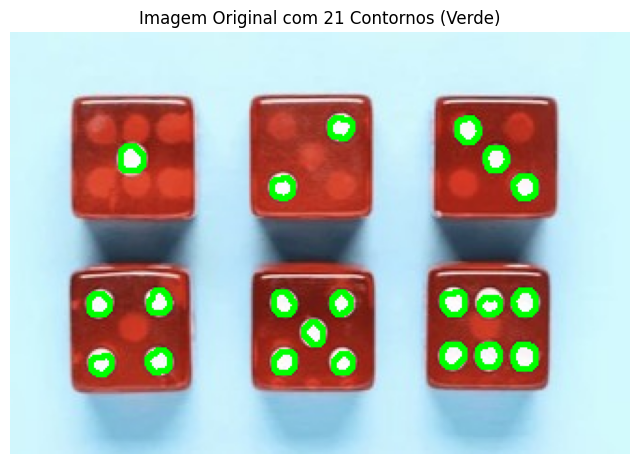

dados_09.jpg: 21 pontos

Carregando imagem: ../data/imagem/dados_10.jpg
Total da pontuação: 13


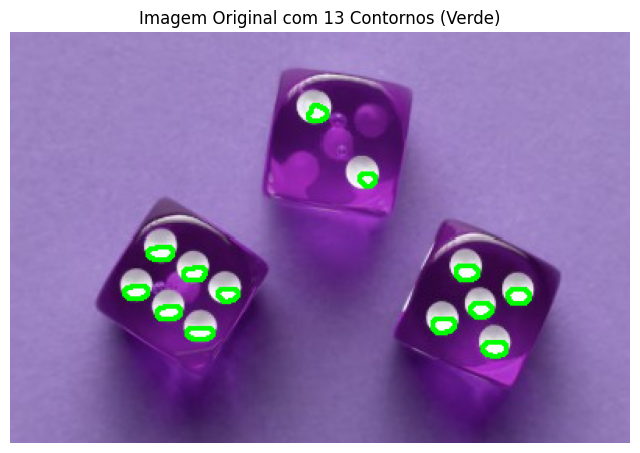

dados_10.jpg: 13 pontos



In [22]:
# Lista das 10 imagens
img_paths = [
    '../data/imagem/dados_01.jpg',
    '../data/imagem/dados_02.jpg',
    '../data/imagem/dados_03.jpg',
    '../data/imagem/dados_04.jpg',
    '../data/imagem/dados_05.jpg',
    '../data/imagem/dados_06.jpg',
    '../data/imagem/dados_07.jpg',
    '../data/imagem/dados_08.jpg',
    '../data/imagem/dados_09.jpg',
    '../data/imagem/dados_10.jpg'
]

# Executar
processar_lote(img_paths)